# Customer Retention Modeling

This notebook develops and evaluates churn-risk classification models using the prepared customer dataset.

The workflow uses a single raw CSV, creates a reproducible stratified train/test split, applies shared feature engineering and preprocessing, compares multiple candidate models with cross-validation, and evaluates the selected model on an untouched test set.

## 1. Imports and Project Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    CV_FOLDS,
    ID_COLUMN,
    RANDOM_STATE,
    RAW_DATA_PATH,
    TARGET_COLUMN,
    TEST_SIZE,
)
from src.features import add_features
from src.modeling import build_candidates, evaluate_predictions
from src.validate_data import load_prepared_data

## 2. Load and Prepare the Dataset

In [2]:
df = load_prepared_data(RAW_DATA_PATH)
df = add_features(df)

print(f"Prepared dataset shape: {df.shape}")
display(df.head())

Prepared dataset shape: (7043, 30)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,LifetimeSpendPerTenure,MonthlyCostExposure,ServiceAdoptionCount,ServiceAdoptionRate,IsRollingContract,IsLongContract,EarlyLifecycleRolling,AccumulatedValueRatio,UsesElectronicPayment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,0,29.850000,1.000000,1,0.166667,1,0,1,1.000000,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,0,55.573529,0.030140,2,0.333333,0,0,0,0.975830,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,54.075000,0.497920,2,0.333333,1,0,1,1.004178,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,0,40.905556,0.022980,3,0.500000,0,0,0,0.967034,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,75.825000,0.466205,0,0.000000,1,0,1,1.072489,1


## 3. Define Target and Predictors

`customerID` is retained separately for customer-level prediction outputs but is excluded from model training.

In [3]:
customer_ids = df[ID_COLUMN].copy()

X = df.drop(columns=[TARGET_COLUMN, ID_COLUMN])
y = df[TARGET_COLUMN]

print("Predictor shape:", X.shape)
print("Target distribution:")
display(y.value_counts(normalize=True).rename("Share"))

Predictor shape: (7043, 28)
Target distribution:


Churn
0    0.73463
1    0.26537
Name: Share, dtype: float64

## 4. Reproducible Stratified Train/Test Split

The raw dataset is split once into training and test sets. Stratification preserves the overall churn-class proportion in both partitions.

In [4]:
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training rows: 5,634
Test rows: 1,409
Training churn rate: 26.54%
Test churn rate: 26.54%


## 5. Candidate Models

Three complementary classification approaches are compared:

- Logistic Regression — interpretable linear baseline
- Random Forest — nonlinear tree ensemble
- LightGBM — gradient-boosted tree model

In [5]:
candidates = build_candidates(
    X_train,
    random_state=RANDOM_STATE,
)

print("Candidate models:")
for model_name in candidates:
    print(f"- {model_name}")

Candidate models:
- Logistic Regression
- Random Forest
- LightGBM


## 6. Cross-Validated Model Comparison

ROC-AUC is used as the primary comparison metric. Average Precision, Log Loss, and Accuracy are also tracked to provide a broader view of model behavior.

In [6]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "neg_log_loss": "neg_log_loss",
    "accuracy": "accuracy",
}

results = []

for name, pipeline in candidates.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    results.append(
        {
            "Model": name,
            "CV_ROC_AUC_Mean": cv_results["test_roc_auc"].mean(),
            "CV_ROC_AUC_Std": cv_results["test_roc_auc"].std(),
            "CV_Average_Precision_Mean": cv_results["test_average_precision"].mean(),
            "CV_Log_Loss_Mean": -cv_results["test_neg_log_loss"].mean(),
            "CV_Accuracy_Mean": cv_results["test_accuracy"].mean(),
        }
    )

comparison = (
    pd.DataFrame(results)
    .sort_values("CV_ROC_AUC_Mean", ascending=False)
    .reset_index(drop=True)
)

display(comparison)

,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_Average_Precision_Mean,CV_Log_Loss_Mean,CV_Accuracy_Mean
0,Logistic Regression,0.850073,0.011607,0.671825,0.483100,0.750802
1,Random Forest,0.842650,0.008295,0.646669,0.462369,0.772455
2,LightGBM,0.839324,0.007163,0.647806,0.463401,0.777247


## 7. Model Comparison Visualization

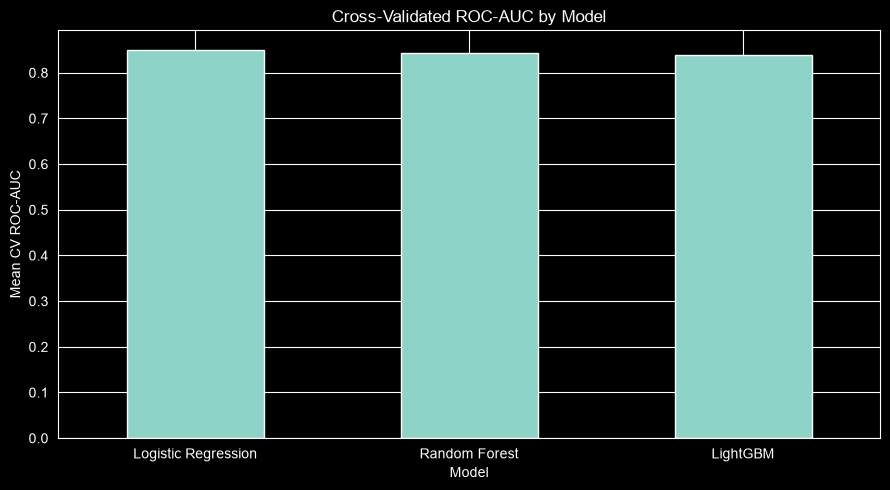

In [7]:
import matplotlib.pyplot as plt

ax = comparison.plot(
    x="Model",
    y="CV_ROC_AUC_Mean",
    kind="bar",
    figsize=(9, 5),
    legend=False,
)

ax.set_title("Cross-Validated ROC-AUC by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Mean CV ROC-AUC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Select the Best Model

The model with the highest mean cross-validated ROC-AUC is selected for final fitting.

In [8]:
best_model_name = comparison.iloc[0]["Model"]
best_model = candidates[best_model_name]

print(f"Selected model: {best_model_name}")

Selected model: Logistic Regression


## 9. Fit the Selected Model

In [9]:
best_model.fit(X_train, y_train)

test_probabilities = best_model.predict_proba(X_test)[:, 1]

test_metrics = evaluate_predictions(
    y_test,
    test_probabilities,
)

metrics_df = pd.DataFrame(
    {
        "Metric": list(test_metrics.keys()),
        "Value": list(test_metrics.values()),
    }
)

display(metrics_df.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,ROC_AUC,0.8482
1,Average_Precision,0.6670
2,Log_Loss,0.4858
3,Accuracy_At_0.5,0.7374


## 10. Customer-Level Churn Probabilities

The selected model produces a probability score rather than only a binary prediction. This allows the output to be used for risk prioritization.

In [10]:
predictions = pd.DataFrame(
    {
        ID_COLUMN: ids_test.values,
        "ActualChurn": y_test.values,
        "ChurnProbability": test_probabilities,
        "PredictedChurn": (test_probabilities >= 0.5).astype(int),
    }
)

predictions = predictions.sort_values(
    "ChurnProbability",
    ascending=False,
).reset_index(drop=True)

display(predictions.head(20))

,customerID,ActualChurn,ChurnProbability,PredictedChurn
0,5178-LMXOP,1,0.980113,1
1,0295-PPHDO,1,0.975256,1
2,1069-XAIEM,1,0.970268,1
3,3722-WPXTK,1,0.966243,1
4,0970-ETWGE,1,0.965490,1
5,7181-BQYBV,1,0.962698,1
6,6230-BSUXY,1,0.958947,1
7,9248-OJYKK,1,0.958642,1
8,2202-CUYXZ,1,0.952906,1
9,4415-IJZTP,1,0.952492,1


## 11. Risk Segmentation

Risk bands provide a simple business-facing interpretation of predicted churn probabilities. These thresholds are illustrative and should be calibrated against intervention costs and retention capacity before operational use.

In [11]:
predictions["RiskSegment"] = pd.cut(
    predictions["ChurnProbability"],
    bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
    labels=["Low", "Moderate", "High", "Very High"],
)

risk_summary = (
    predictions.groupby("RiskSegment", observed=False)
    .agg(
        Customers=(ID_COLUMN, "count"),
        AverageChurnProbability=("ChurnProbability", "mean"),
        ActualChurnRate=("ActualChurn", "mean"),
    )
)

display(
    risk_summary.style.format(
        {
            "AverageChurnProbability": "{:.2%}",
            "ActualChurnRate": "{:.2%}",
        }
    )
)

,Customers,AverageChurnProbability,ActualChurnRate
RiskSegment,,,
Low,567,9.79%,4.23%
Moderate,246,36.83%,20.33%
High,323,62.93%,35.60%
Very High,273,84.96%,67.77%


## 12. Highest-Risk Customers

The following view shows customers receiving the highest predicted churn probabilities in the held-out test set.

In [12]:
high_risk_customers = predictions.loc[
    predictions["ChurnProbability"] >= 0.75
].copy()

print(f"Customers classified as very high risk: {len(high_risk_customers):,}")

display(high_risk_customers.head(20))

Customers classified as very high risk: 273


,customerID,ActualChurn,ChurnProbability,PredictedChurn,RiskSegment
0,5178-LMXOP,1,0.980113,1,Very High
1,0295-PPHDO,1,0.975256,1,Very High
2,1069-XAIEM,1,0.970268,1,Very High
3,3722-WPXTK,1,0.966243,1,Very High
4,0970-ETWGE,1,0.965490,1,Very High
5,7181-BQYBV,1,0.962698,1,Very High
6,6230-BSUXY,1,0.958947,1,Very High
7,9248-OJYKK,1,0.958642,1,Very High
8,2202-CUYXZ,1,0.952906,1,Very High
9,4415-IJZTP,1,0.952492,1,Very High


## 13. Model Interpretation Notes

The project is designed around risk identification rather than causal inference. A high churn probability means that the model finds the customer's observed characteristics similar to patterns associated with churn in the training data.

Before production use, probability calibration, threshold selection, intervention costs, customer-contact capacity, fairness checks, and monitoring should be considered.

## 14. Conclusion

The modeling workflow compares several classification approaches under the same preprocessing and validation framework. The selected model is evaluated on a held-out test set and produces customer-level churn probabilities that can support retention prioritization.

The notebook intentionally calculates all performance metrics during execution rather than embedding fixed performance numbers.